In [2]:
import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# VaR & CVaR
risk_metrics = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: pd.Series({
        "VaR_95": np.percentile(x.dropna(), 5),
        "CVaR_95": x[x <= np.percentile(x.dropna(), 5)].mean()
    })
).unstack()

risk_metrics = risk_metrics.reset_index()

# Save report
risk_metrics.to_csv("../reports/var_cvar_report.csv", index=False)

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


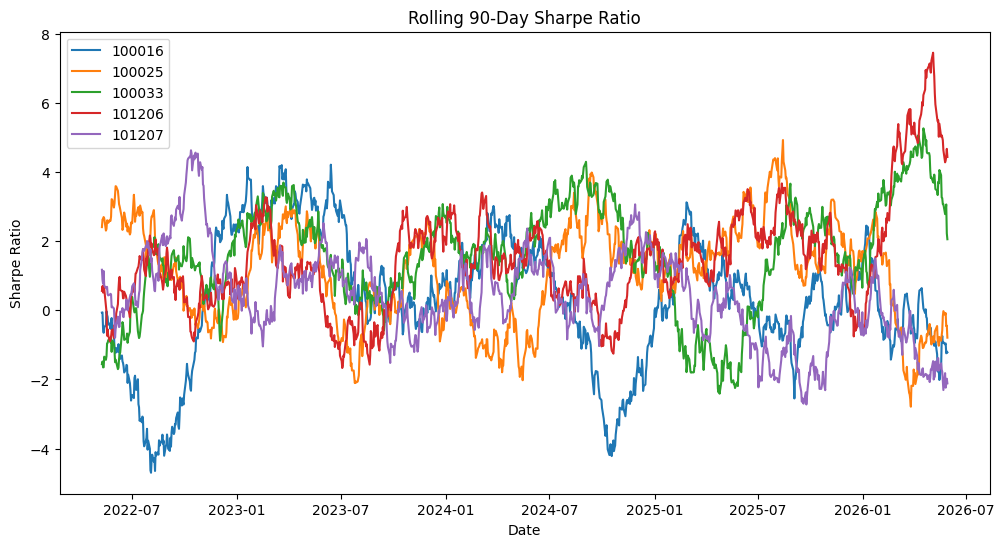

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Select first 5 funds
top_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:
    temp = nav[nav["amfi_code"] == fund].copy()

    temp["sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(temp["date"], temp["sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [4]:
import pandas as pd

tx = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

# First investment year
cohort = tx.groupby("investor_id")["transaction_date"].min().dt.year

tx["cohort_year"] = tx["investor_id"].map(cohort)

# Average SIP amount
avg_sip = (
    tx[tx["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
)

# Total invested
total_inv = (
    tx.groupby("cohort_year")["amount_inr"]
    .sum()
)

# Top fund preference
top_fund = (
    tx.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

cohort_report = pd.DataFrame({
    "avg_sip_amount": avg_sip,
    "total_invested": total_inv
}).reset_index()

cohort_report = cohort_report.merge(
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year"
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [5]:
import pandas as pd

tx = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

# SIP only
sip = tx[tx["transaction_type"] == "SIP"].copy()

# Investors with 6+ SIPs
sip_counts = sip.groupby("investor_id").size()

eligible = sip_counts[sip_counts >= 6].index

sip = sip[sip["investor_id"].isin(eligible)]

# Sort by investor and date
sip = sip.sort_values(["investor_id", "transaction_date"])

# Gap between SIPs
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

# Average gap
continuity = sip.groupby("investor_id")["gap_days"].mean().reset_index()

continuity["status"] = continuity["gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Healthy"
)

continuity.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


# Advanced Insights

## 1. Risk Analysis
Funds with the most negative VaR and CVaR values exhibit the highest downside risk and may experience larger losses during adverse market conditions.

## 2. Investor Cohort Behavior
The 2024 investor cohort contributed the highest total investment amount and represents the largest investor group in the dataset.

## 3. SIP Continuity
A significant number of investors have average SIP gaps greater than 35 days and are classified as At-Risk, indicating potential discontinuation of investments.

## 4. Rolling Sharpe Performance
Several funds achieved consistently positive rolling 90-day Sharpe ratios, demonstrating superior risk-adjusted performance over time.

## 5. Fund Recommendation Insights
Low-risk funds with strong 5-year returns and low expense ratios were identified as the most suitable recommendations for conservative investors.